Task 1: Data Preparation and EDA

E:\Temp\ipykernel_36944\4060056350.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('Books.csv', encoding='latin-1')


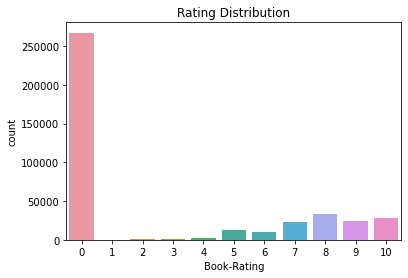

Top active users:
 153662    2782
76352     2260
198711    2112
98391     1821
16795     1726
Name: User-ID, dtype: int64
Top rated books:
 Wild Animus                   1366
The Lovely Bones: A Novel      748
The Da Vinci Code              573
Bridget Jones's Diary          516
The Nanny Diaries: A Novel     487
Name: Book-Title, dtype: int64


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
books = pd.read_csv('Books.csv', encoding='latin-1')
users = pd.read_csv('Users.csv', encoding='latin-1')
ratings = pd.read_csv('Ratings.csv', encoding='latin-1')

# Merge datasets
df = ratings.merge(books, on='ISBN').merge(users, on='User-ID')

# Drop missing values
df.dropna(inplace=True)

# Remove duplicate ratings
df.drop_duplicates(subset=['User-ID', 'ISBN'], inplace=True)

# Filter: users with >= 5 ratings
user_counts = df['User-ID'].value_counts()
df = df[df['User-ID'].isin(user_counts[user_counts >= 5].index)]

# Filter: books with >= 5 ratings
book_counts = df['ISBN'].value_counts()
df = df[df['ISBN'].isin(book_counts[book_counts >= 5].index)]

# EDA: Rating distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Book-Rating', data=df)
plt.title('Rating Distribution')
plt.show()

# Active users
top_users = df['User-ID'].value_counts().head(5)
print("Top active users:\n", top_users)

# Popular books
top_books = df['Book-Title'].value_counts().head(5)
print("Top rated books:\n", top_books)


Task 2: User-Based Collaborative Filtering

In [7]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# Create user-item matrix
user_item_matrix = df.pivot_table(index='User-ID', columns='Book-Title', values='Book-Rating').fillna(0)

# Compute cosine similarity between users
user_similarity = cosine_similarity(user_item_matrix)
user_sim_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

# Choose a user
target_user = user_item_matrix.index[0]
similar_users = user_sim_df[target_user].sort_values(ascending=False)[1:6]
print("Top 5 similar users:\n", similar_users)

# Recommend top 5 books
similar_user_ids = similar_users.index
similar_users_books = user_item_matrix.loc[similar_user_ids]
mean_ratings = similar_users_books.mean().sort_values(ascending=False)
unseen_books = user_item_matrix.loc[target_user] == 0
recommendations = mean_ratings[unseen_books].head(5)
print("Top 5 recommended books for user:", target_user)
print(recommendations)


Top 5 similar users:
 User-ID
112614    1.000000
101422    0.402139
94385     0.326860
30029     0.217584
225810    0.215587
Name: 44, dtype: float64
Top 5 recommended books for user: 44
Book-Title
Light a Penny Candle                          2.4
On the Beach                                  2.0
The Thorn Birds                               2.0
UNLIKELY ONES                                 2.0
Milk and Honey (Decker and Lazarus Series)    2.0
dtype: float64


Task 3: Item-Based Collaborative Filtering

In [12]:
# Create a mapping from ISBN to Book-Title
isbn_to_title = books.set_index('ISBN')['Book-Title'].to_dict()

# Limit to top N popular books to reduce memory usage
top_books = ratings['ISBN'].value_counts().head(500).index
filtered_ratings = ratings[ratings['ISBN'].isin(top_books)]

user_item_matrix = filtered_ratings.pivot_table(index='User-ID', columns='ISBN', values='Book-Rating').fillna(0)
item_user_matrix = user_item_matrix.T

from sklearn.metrics.pairwise import cosine_similarity
item_similarity = cosine_similarity(item_user_matrix)

item_sim_df = pd.DataFrame(item_similarity, 
                           index=item_user_matrix.index, 
                           columns=item_user_matrix.index)

# Example: Find top 5 similar books to a given ISBN
book_id = item_user_matrix.index[0]  # Pick one ISBN
similar_books = item_sim_df[book_id].sort_values(ascending=False).head(6)[1:]

# Print with book titles
print(f"\nBooks similar to '{isbn_to_title.get(book_id, 'Unknown Title')}'\n")
for sim_isbn, score in similar_books.items():
    title = isbn_to_title.get(sim_isbn, "Unknown Title")
    print(f"{title} (ISBN: {sim_isbn}) - Similarity: {score:.2f}")



Books similar to 'Politically Correct Bedtime Stories: Modern Tales for Our Life and Times'

L Is for Lawless (ISBN: 0449221490) - Similarity: 0.06
Anne of Green Gables (Anne of Green Gables Novels (Paperback)) (ISBN: 055321313X) - Similarity: 0.06
The Hundred Secret Senses (ISBN: 080411109X) - Similarity: 0.05
Lucky : A Memoir (ISBN: 0316096199) - Similarity: 0.05
Charlotte's Web (Trophy Newbery) (ISBN: 0064400557) - Similarity: 0.05
